# 451 Financial Engineering: Programming Assignment 1
## AAPL Return Prediction 
Michael Dawson

In [2]:
!pip install polars pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 824.0/824.0 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 50.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [polars]2m1/2 [polars]


In [5]:
pip install yfinance

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 27.6 MB/s eta 0:00:00
  DEPRECATION: Building 'multitasking' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'multitasking'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15548 sha256=005d82c72eb129b38d78808cef9d29f2cb9229a83d40195539c295a66d6dae6e
  Stored in directory: /Users/dawson/Library/Caches/pip/wheels/1e/df/0f/e2bbb22d689b30c681feb5410ab64a2523437b34c8ecfc6476
Successfully built multitasking
  Attempting uninstall: cffi
    Found existing installation: cffi 1.17.1
    Uninstalling cffi-

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)

# data manipulation
import numpy as np
import pyarrow
import polars as pl

# plotting
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# preprocessing + model selection
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit, cross_validate

# models
from sklearn.linear_model import LogisticRegression

# metrics
from sklearn.metrics import (log_loss, accuracy_score, classification_report,
                             roc_curve, roc_auc_score, RocCurveDisplay,
                             ConfusionMatrixDisplay, confusion_matrix,
                             precision_score, recall_score, f1_score)

# xgboost
import xgboost as xgb
from xgboost import XGBRegressor, XGBClassifier, plot_importance

# randomized search distributions
from scipy.stats import randint, uniform

In [2]:
import yfinance as yf

symbol = 'AAPL'
start_date = '2010-01-01'
end_date   = '2026-04-16'

ticker = yf.Ticker(symbol)
historical_data = ticker.history(start=start_date, end=end_date)
print(historical_data.head())
print('shape:', historical_data.shape)

historical_data.to_csv('aapl_historical_data.csv')

                               Open      High       Low     Close     Volume  \
Date                                                                           
2010-01-04 00:00:00-05:00  6.395004  6.427064  6.363543  6.412382  493729600   
2010-01-05 00:00:00-05:00  6.430061  6.459724  6.389610  6.423469  601904800   
2010-01-06 00:00:00-05:00  6.423471  6.448940  6.314705  6.321297  552160000   
2010-01-07 00:00:00-05:00  6.344667  6.352157  6.263766  6.309609  477131200   
2010-01-08 00:00:00-05:00  6.301220  6.352158  6.264067  6.351558  447610800   

                           Dividends  Stock Splits  
Date                                                
2010-01-04 00:00:00-05:00        0.0           0.0  
2010-01-05 00:00:00-05:00        0.0           0.0  
2010-01-06 00:00:00-05:00        0.0           0.0  
2010-01-07 00:00:00-05:00        0.0           0.0  
2010-01-08 00:00:00-05:00        0.0           0.0  
shape: (4095, 7)


In [3]:
# feature engineering

aapl = pl.read_csv('aapl_historical_data.csv', try_parse_dates=True)

print('original schema:', aapl.schema)

# drop junk columns if present (yfinance versions vary on naming)
drop_cols = [c for c in ['Dividends', 'Stock Splits', 'StockSplits', 'Capital Gains']
             if c in aapl.columns]
aapl = aapl.drop(drop_cols)

# lag close
aapl = aapl.with_columns((pl.col('Close')).shift().alias('CloseLag1'))
aapl = aapl.with_columns((pl.col('CloseLag1')).shift().alias('CloseLag2'))
aapl = aapl.with_columns((pl.col('CloseLag2')).shift().alias('CloseLag3'))

# HML and lags
aapl = aapl.with_columns((pl.col('High') - pl.col('Low')).alias('HML'))
aapl = aapl.with_columns((pl.col('HML')).shift().alias('HMLLag1'))
aapl = aapl.with_columns((pl.col('HMLLag1')).shift().alias('HMLLag2'))
aapl = aapl.with_columns((pl.col('HMLLag2')).shift().alias('HMLLag3'))

# OMC and lags
aapl = aapl.with_columns((pl.col('Open') - pl.col('Close')).alias('OMC'))
aapl = aapl.with_columns((pl.col('OMC')).shift().alias('OMCLag1'))
aapl = aapl.with_columns((pl.col('OMCLag1')).shift().alias('OMCLag2'))
aapl = aapl.with_columns((pl.col('OMCLag2')).shift().alias('OMCLag3'))

# volume lags
aapl = aapl.with_columns((pl.col('Volume')).shift().alias('VolumeLag1'))
aapl = aapl.with_columns((pl.col('VolumeLag1')).shift().alias('VolumeLag2'))
aapl = aapl.with_columns((pl.col('VolumeLag2')).shift().alias('VolumeLag3'))

# EMAs of CloseLag1 (no leakage)
aapl = aapl.with_columns((pl.col('CloseLag1').ewm_mean(half_life=1, ignore_nulls=True)).alias('CloseEMA2'))
aapl = aapl.with_columns((pl.col('CloseLag1').ewm_mean(half_life=2, ignore_nulls=True)).alias('CloseEMA4'))
aapl = aapl.with_columns((pl.col('CloseLag1').ewm_mean(half_life=4, ignore_nulls=True)).alias('CloseEMA8'))

# log return
aapl = aapl.with_columns(np.log(pl.col('Close') / pl.col('CloseLag1')).alias('LogReturn'))

# cast volumes to float for later numpy use
aapl = aapl.with_columns(
    pl.col('Volume').cast(pl.Float64).round(0),
    pl.col('VolumeLag1').cast(pl.Float64).round(0),
    pl.col('VolumeLag2').cast(pl.Float64).round(0),
    pl.col('VolumeLag3').cast(pl.Float64).round(0),
)

# round prices 
price_cols = ['Open','High','Low','Close',
              'CloseLag1','CloseLag2','CloseLag3',
              'HML','HMLLag1','HMLLag2','HMLLag3',
              'OMC','OMCLag1','OMCLag2','OMCLag3',
              'CloseEMA2','CloseEMA4','CloseEMA8']
aapl = aapl.with_columns([pl.col(c).round(3) for c in price_cols])

# binary target
aapl = aapl.with_columns(
    pl.when(pl.col('LogReturn') > 0.0).then(pl.lit(1)).otherwise(pl.lit(0)).alias('Target')
)

# drop initial rows with null lags
aapl = aapl.drop_nulls()

print('final row count:', aapl.height)
print('date range:', aapl['Date'].min(), 'to', aapl['Date'].max())

aapl.write_csv('aapl-with-computed-features.csv')


original schema: Schema({'Date': Datetime(time_unit='us', time_zone='UTC'), 'Open': Float64, 'High': Float64, 'Low': Float64, 'Close': Float64, 'Volume': Int64, 'Dividends': Float64, 'Stock Splits': Float64})
final row count: 4092
date range: 2010-01-07 05:00:00+00:00 to 2026-04-15 04:00:00+00:00


In [6]:
HOLDOUT_FRAC = 0.15
GAP = 10 

n_total   = aapl.height
n_holdout = int(HOLDOUT_FRAC * n_total)
n_train   = n_total - n_holdout - GAP

train   = aapl.slice(0, n_train)
holdout = aapl.slice(n_train + GAP, n_holdout)

print(f'total rows:   {n_total}')
print(f'train:        {train.height} rows   ({train["Date"].min()} to {train["Date"].max()})')
print(f'gap:          {GAP} rows')
print(f'holdout:      {holdout.height} rows   ({holdout["Date"].min()} to {holdout["Date"].max()})')

total rows:   4092
train:        3469 rows   (2010-01-07 05:00:00+00:00 to 2023-10-18 04:00:00+00:00)
gap:          10 rows
holdout:      613 rows   (2023-11-02 04:00:00+00:00 to 2026-04-15 04:00:00+00:00)


## EDA

In [7]:
trainStatistics = train.drop('Date').describe()
trainStatisticsToPrint = trainStatistics.transpose(include_header=True).drop(['column_1','column_5','column_7'])

with pl.Config(tbl_rows=60, tbl_width_chars=200, tbl_cols=-1,
               float_precision=3, tbl_hide_dataframe_shape=True,
               tbl_hide_column_data_types=True):
    print(trainStatisticsToPrint)

┌────────────┬──────────┬───────────────────────┬──────────────────────┬──────────────────────┬───────────────────────┬─────────────────────┐
│ column     ┆ column_0 ┆ column_2              ┆ column_3             ┆ column_4             ┆ column_6              ┆ column_8            │
╞════════════╪══════════╪═══════════════════════╪══════════════════════╪══════════════════════╪═══════════════════════╪═════════════════════╡
│ statistic  ┆ count    ┆ mean                  ┆ std                  ┆ min                  ┆ 50%                   ┆ max                 │
│ Open       ┆ 3469.0   ┆ 55.49515162871145     ┆ 53.44775252093122    ┆ 5.764                ┆ 28.523                ┆ 193.705             │
│ High       ┆ 3469.0   ┆ 56.1050305563563      ┆ 54.07723207053807    ┆ 5.873                ┆ 28.708                ┆ 195.669             │
│ Low        ┆ 3469.0   ┆ 54.91340328624964     ┆ 52.86869819681758    ┆ 5.7                  ┆ 28.328                ┆ 192.758             │
│ Clos

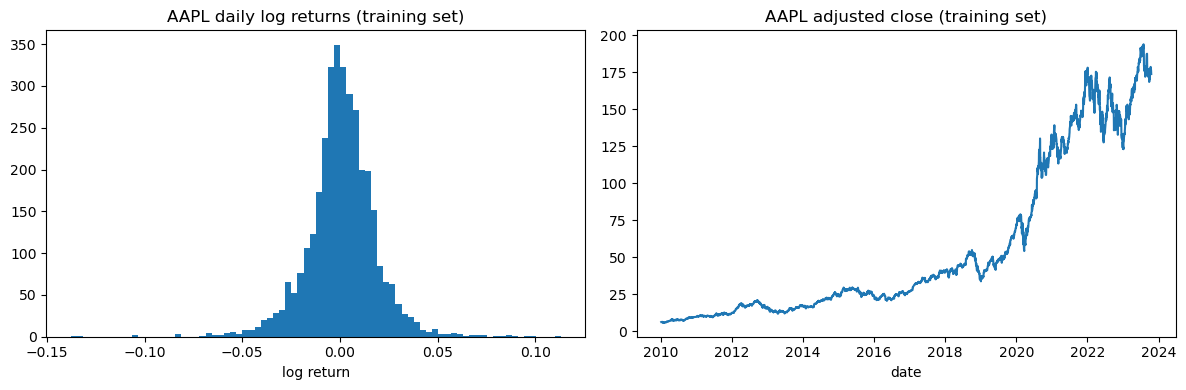

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(train['LogReturn'].to_numpy(), bins=80)
ax[0].set_title('AAPL daily log returns (training set)')
ax[0].set_xlabel('log return')
ax[1].plot(train['Date'].to_numpy(), train['Close'].to_numpy())
ax[1].set_title('AAPL adjusted close (training set)')
ax[1].set_xlabel('date')
plt.tight_layout()
plt.show()

## Classification Target

In [9]:
feature_drop = ['Date','LogReturn','Target','Open','High','Low','Close','Volume','HML','OMC']

X_train_df   = train.drop(feature_drop)
X_holdout_df = holdout.drop(feature_drop)

featureNames = X_train_df.columns
print('feature columns:', featureNames)

# classification target
y_train   = np.array(train['Target'])
y_holdout = np.array(holdout['Target'])

# regression target (kept for later sections)
r_train   = np.array(train['LogReturn'])
r_holdout = np.array(holdout['LogReturn'])

print()
print('class balance (train):  ', dict(zip(*np.unique(y_train, return_counts=True))))
print('class balance (holdout):', dict(zip(*np.unique(y_holdout, return_counts=True))))

feature columns: ['CloseLag1', 'CloseLag2', 'CloseLag3', 'HMLLag1', 'HMLLag2', 'HMLLag3', 'OMCLag1', 'OMCLag2', 'OMCLag3', 'VolumeLag1', 'VolumeLag2', 'VolumeLag3', 'CloseEMA2', 'CloseEMA4', 'CloseEMA8']

class balance (train):   {np.int32(0): np.int64(1636), np.int32(1): np.int64(1833)}
class balance (holdout): {np.int32(0): np.int64(283), np.int32(1): np.int64(330)}


In [10]:
scaler = StandardScaler()
X_train   = scaler.fit_transform(np.array(X_train_df))
X_holdout = scaler.transform(np.array(X_holdout_df))

print('X_train shape:  ', X_train.shape)
print('X_holdout shape:', X_holdout.shape)

X_train shape:   (3469, 15)
X_holdout shape: (613, 15)


## Model Training

In [11]:
tscv = TimeSeriesSplit(n_splits=5, gap=10)

param_dist = {
    'n_estimators':     randint(100, 600),
    'max_depth':        randint(2, 8),
    'learning_rate':    uniform(0.01, 0.2),
    'subsample':        uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 10),
    'reg_alpha':        uniform(0.0, 1.0),
    'reg_lambda':       uniform(0.0, 1.0),
}

clf = XGBClassifier(objective='binary:logistic', eval_metric='logloss',
                    tree_method='hist', random_state=42)

search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=tscv,
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

search.fit(X_train, y_train)

print()
print('best CV AUC (train set):', round(search.best_score_, 4))
print('best params:', search.best_params_)

best_model = search.best_estimator_

Fitting 5 folds for each of 50 candidates, totalling 250 fits

best CV AUC (train set): 0.5125
best params: {'colsample_bytree': np.float64(0.8211572356285312), 'learning_rate': np.float64(0.12853934477587872), 'max_depth': 4, 'min_child_weight': 8, 'n_estimators': 222, 'reg_alpha': np.float64(0.24215993827742588), 'reg_lambda': np.float64(0.8031397563798959), 'subsample': np.float64(0.7881202537784153)}


In [12]:
y_train_pred = best_model.predict(X_train)
y_train_prob = best_model.predict_proba(X_train)[:, 1]

print('training-set fit diagnostics')
print('  accuracy:', round(accuracy_score(y_train, y_train_pred), 4))
print('  AUC:     ', round(roc_auc_score(y_train, y_train_prob), 4))

training-set fit diagnostics
  accuracy: 0.8325
  AUC:      0.9152


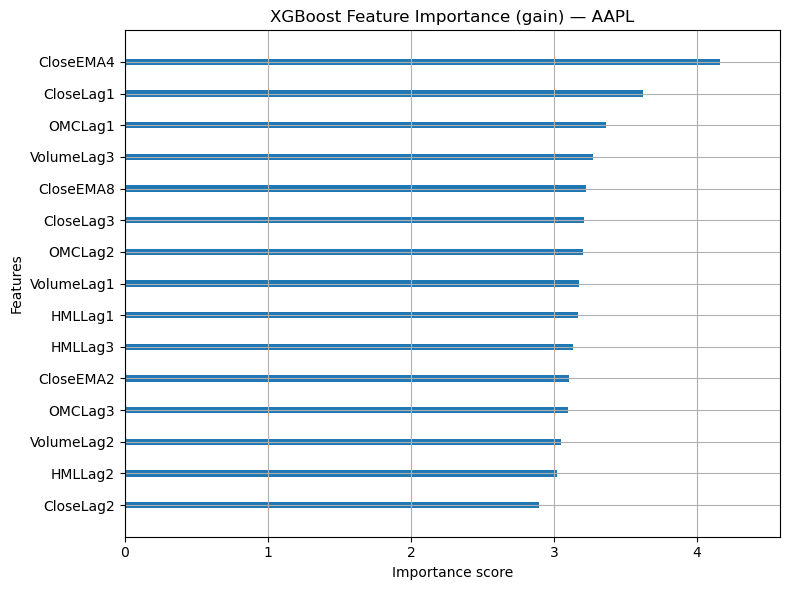

In [13]:
booster = best_model.get_booster()
booster.feature_names = list(featureNames)

fig, ax = plt.subplots(figsize=(8, 6))
plot_importance(booster, ax=ax, importance_type='gain', show_values=False)
plt.title('XGBoost Feature Importance (gain) — AAPL')
plt.tight_layout()
plt.show()

## Results

In [14]:
y_holdout_pred = best_model.predict(X_holdout)
y_holdout_prob = best_model.predict_proba(X_holdout)[:, 1]

print('=' * 50)
print('HOLD-OUT TEST SET RESULTS')
print('=' * 50)
print(f'holdout period: {holdout["Date"].min()} to {holdout["Date"].max()}')
print(f'holdout rows:   {len(y_holdout)}')
print()
print('accuracy:', round(accuracy_score(y_holdout, y_holdout_pred), 4))
print('AUC:     ', round(roc_auc_score(y_holdout, y_holdout_prob), 4))
print('precision:', round(precision_score(y_holdout, y_holdout_pred), 4))
print('recall:   ', round(recall_score(y_holdout, y_holdout_pred), 4))
print('f1:       ', round(f1_score(y_holdout, y_holdout_pred), 4))
print()
print('classification report:')
print(classification_report(y_holdout, y_holdout_pred))

HOLD-OUT TEST SET RESULTS
holdout period: 2023-11-02 04:00:00+00:00 to 2026-04-15 04:00:00+00:00
holdout rows:   613

accuracy: 0.4894
AUC:      0.4804
precision: 0.5242
recall:    0.5576
f1:        0.5404

classification report:
              precision    recall  f1-score   support

           0       0.44      0.41      0.43       283
           1       0.52      0.56      0.54       330

    accuracy                           0.49       613
   macro avg       0.48      0.48      0.48       613
weighted avg       0.49      0.49      0.49       613



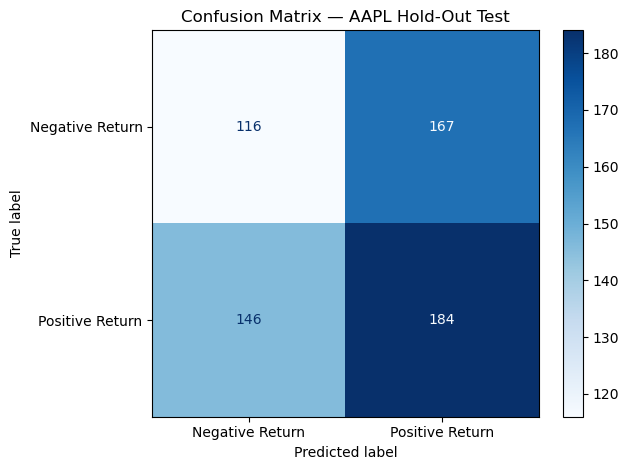

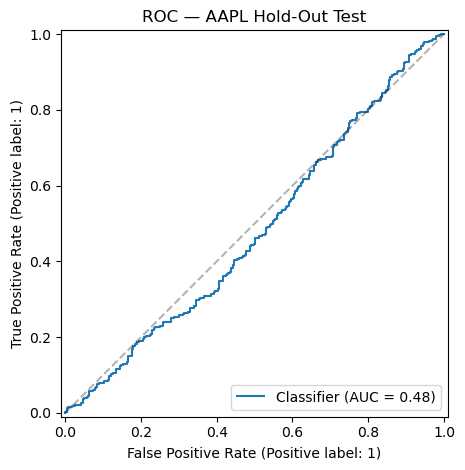

In [15]:
# confusion matrix on holdout
ConfusionMatrixDisplay.from_predictions(
    y_holdout, y_holdout_pred,
    display_labels=['Negative Return', 'Positive Return'],
    cmap=plt.cm.Blues,
)
plt.title('Confusion Matrix — AAPL Hold-Out Test')
plt.tight_layout()
plt.show()

# ROC curve on holdout
RocCurveDisplay.from_predictions(y_holdout, y_holdout_prob)
plt.title('ROC — AAPL Hold-Out Test')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
majority_class = int(np.bincount(y_train).argmax())
y_majority = np.full_like(y_holdout, majority_class)

print('majority class (from train):', majority_class)
print('majority-class accuracy on holdout:', round(accuracy_score(y_holdout, y_majority), 4))
print('XGBoost accuracy on holdout:       ', round(accuracy_score(y_holdout, y_holdout_pred), 4))
print()
print('XGBoost AUC on holdout:', round(roc_auc_score(y_holdout, y_holdout_prob), 4))
print('(AUC = 0.5 is a coin flip; >0.55 starts to be interesting for daily stock direction)')

majority class (from train): 1
majority-class accuracy on holdout: 0.5383
XGBoost accuracy on holdout:        0.4894

XGBoost AUC on holdout: 0.4804
(AUC = 0.5 is a coin flip; >0.55 starts to be interesting for daily stock direction)
